#A/B Testing Analysis: Old Page vs New Page

**Objective**:
Determine whether the new landing page results in a statistically significant
increase in conversion rate compared to the existing (old) landing page.

**Dataset**:
- User-level session data
- Control and treatment experiment groups
- Binary conversion outcome (0 = no conversion, 1 = conversion)

**Methodology**:
- Data cleaning and experiment validation
- Exploratory Data Analysis (EDA)
- Conversion rate comparison
- Two-sample Z-test for proportions
- Time-based user behavior analysis

Author: **Alok Negi**





In [ ]:
import pandas as pd        # Data manipulation and aggregation
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Base plotting
import seaborn as sns      # Statistical visualizations


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load final cleaned A/B testing dataset
# This dataset already has:
# - duplicate users removed
# - mismatched group-page rows filtered

df = pd.read_csv(
    '/content/drive/MyDrive/ab_final.csv',
    header=None,
    names=[
        'user_id',
        'session_duration',
        'user_group',
        'landing_page',
        'converted',
        'country'
    ]
)


In [ ]:
df

,user_id,session_duration,user_group,landing_page,converted,country
0,791703,15:02.4,control,old_page,0,US\r
1,662835,01:27.2,control,old_page,0,US\r
2,738189,53:02.8,treatment,new_page,0,US\r
3,819791,57:38.6,treatment,new_page,0,US\r
4,719330,04:44.8,treatment,new_page,0,US\r
...,...,...,...,...,...,...
286685,741266,09:49.8,control,old_page,0,US\r
286686,823858,40:14.1,treatment,new_page,0,UK\r
286687,662054,56:30.4,treatment,new_page,0,CA\r
286688,836721,37:51.0,treatment,new_page,0,US\r


In [ ]:
df.shape

(286690, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286690 entries, 0 to 286689
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_id           286690 non-null  int64 
 1   session_duration  286690 non-null  object
 2   user_group        286690 non-null  object
 3   landing_page      286690 non-null  object
 4   converted         286690 non-null  int64 
 5   country           286690 non-null  object
dtypes: int64(2), object(4)
memory usage: 13.1+ MB


In [ ]:
# Remove trailing spaces from country values
# (Important for correct groupby operations)
df["country"] = df["country"].str.strip()

In [ ]:
# Convert session duration (mm:ss.ms) into total seconds
# This enables numerical time-based analysis
df['time_seconds'] = (
    pd.to_timedelta('00:' + df['session_duration'])
      .dt.total_seconds()
)

In [183]:
df.groupby('user_group')['converted'].mean()

,converted
user_group,
control,0.120173
treatment,0.118726


<Axes: xlabel='user_group'>

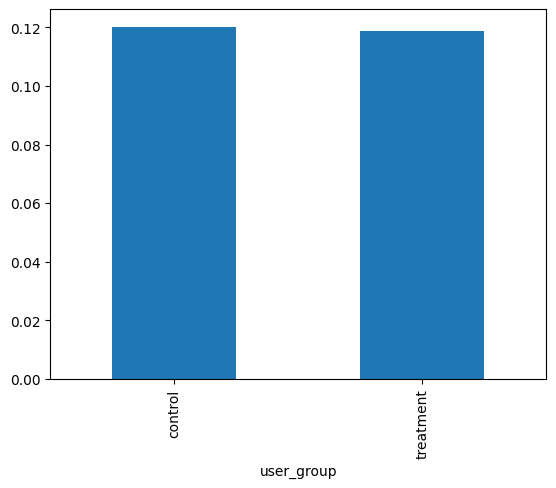

In [180]:
df.groupby('user_group')['converted'].mean().plot(kind='bar')


In [ ]:
# Convert seconds to minutes for easier interpretation
df['time_minutes'] = df['time_seconds'] / 60

# Create session duration bins (0–10, 10–20, ..., 50–60 minutes)
# Helps analyze user engagement patterns across time ranges
df['time_bin'] = pd.cut(
    df['time_minutes'],
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=[
        '0–10 min',
        '10–20 min',
        '20–30 min',
        '30–40 min',
        '40–50 min',
        '50–60 min'
    ],
    include_lowest=True
)


In [189]:
# Aggregate conversion behavior by session time bins
# count  → total users
# sum    → total conversions
# mean   → conversion rate

xx=df.groupby('time_bin')['converted'].agg(count='count', converted='sum', conversion_rate='mean')
xx

/tmp/ipython-input-2314926582.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xx=df.groupby('time_bin')['converted'].agg(count='count', converted='sum', conversion_rate='mean')


,count,converted,conversion_rate
time_bin,,,
0–10 min,47583,5707,0.119938
10–20 min,47468,5595,0.117869
20–30 min,48046,5773,0.120156
30–40 min,47793,5786,0.121064
40–50 min,47997,5729,0.119362
50–60 min,47803,5655,0.118298


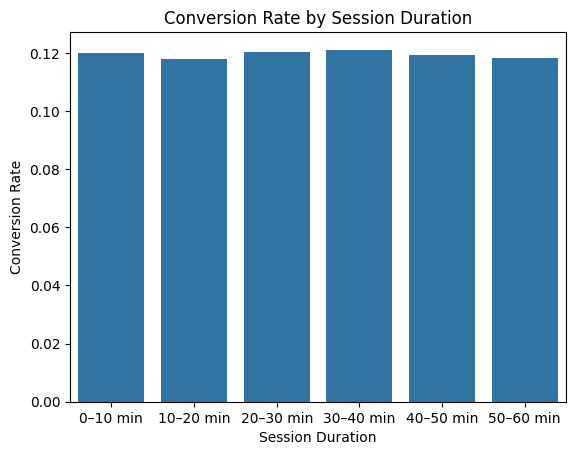

In [190]:
# Helps analyze how user engagement time impacts likelihood of conversion
sns.barplot(
    data=xx,
    x='time_bin',
    y='conversion_rate'
)
plt.title('Conversion Rate by Session Duration')
plt.xlabel('Session Duration')
plt.ylabel('Conversion Rate')
plt.show()


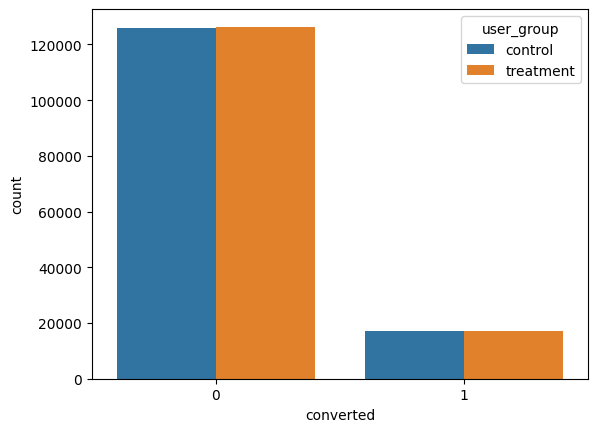

In [ ]:
# Visualize conversion outcomes (0 = no conversion, 1 = conversion)
# split by control and treatment groups.
sns.countplot(data=df, x="converted", hue="user_group")
plt.show()

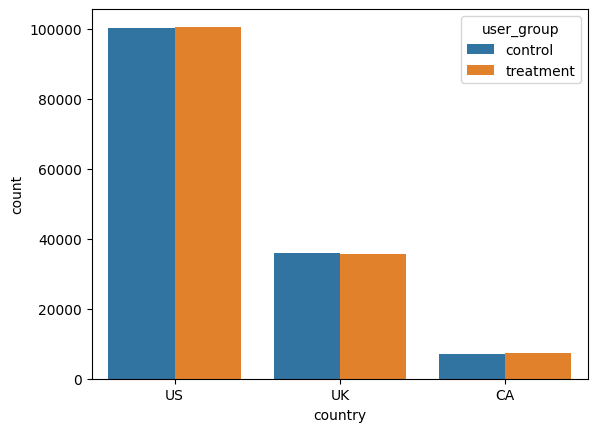

In [ ]:
# Visualize user distribution by country for control and treatment groups
sns.countplot(data=df, x="country", hue="user_group")
plt.show()

In [187]:
df.groupby(['country','user_group'])['converted'].agg(count='count', converted='sum', conversion_rate='mean')

count  converted  conversion_rate
country user_group                                    
CA      control       7094        844         0.118974
        treatment     7209        810         0.112360
UK      control      35883       4295         0.119695
        treatment    35630       4317         0.121162
US      control     100316      12081         0.120429
        treatment   100558      11898         0.118320

# **A/B TESTING**

## 🔹 Step 1: Sample Conversion Rates

The conversion rate is defined as:


$$
\hat{p} = \frac{\text{Number of Conversions}}{\text{Total Users}}
$$

**Control Group**

$$
\hat{p}_c = \frac{17220}{143293} = 0.120173
$$

**Treatment Group**

$$
\hat{p}_t = \frac{17025}{143397} = 0.118726
$$


In [181]:
df.groupby('user_group')['converted'].mean()

,converted
user_group,
control,0.120173
treatment,0.118726


## 🔹 Step 2: Hypothesis Formulation

**Null Hypothesis**

$$
H_0 : p_t = p_c
$$

**Alternative Hypothesis**

$$
H_1 : p_t \neq p_c
$$



In [188]:
# Split dataset into control and treatment groups
control = df[df["user_group"] == "control"]
treatment = df[df["user_group"] == "treatment"]

# Calculate total users and conversions per group
control_converted = control["converted"].sum()
control_users = control.shape[0]

treatment_converted = treatment["converted"].sum()
treatment_users = treatment.shape[0]

control_converted, control_users, treatment_converted, treatment_users


(np.int64(17220), 143293, np.int64(17025), 143397)

## 🔹 Step 3: Pooled Conversion Rate

Under the null hypothesis, both groups are assumed to have the same true conversion rate.

$$
\hat{p} = \frac{x_c + x_t}{n_c + n_t}
$$

$$
\hat{p} = \frac{17220 + 17025}{143293 + 143397}
$$

$$
\hat{p} = \frac{34245}{286690} = 0.119449
$$



## 🔹 Step 4: Standard Error of the Difference

$$
SE = \sqrt{
\hat{p}(1 - \hat{p})
\left(
\frac{1}{n_c} + \frac{1}{n_t}
\right)
}
$$

$$
SE = \sqrt{
0.119449 \times 0.880551
\left(
\frac{1}{143293} + \frac{1}{143397}
\right)
}
$$

$$
SE \approx 0.001212
$$


For a two-tailed test:

$$
p = 2 \times P(Z \le -|z|)
$$

$$
p = 2 \times P(Z \le -1.19)
$$

$$
p \approx 0.232
$$



## 🔹 Step 5: Z-Test Statistic

$$
Z = \frac{\hat{p}_t - \hat{p}_c}{SE}
$$

$$
Z = \frac{0.118726 - 0.120173}{0.001212}
$$

$$
Z \approx -1.19
$$



## 🔹 Step 6: P-Value Calculation

For a two-tailed test:

$$
p = 2 \times P(Z \le -|z|)
$$

$$
p = 2 \times P(Z \le -1.19)
$$

$$
p \approx 0.232
$$

In [ ]:
# Perform two-sample Z-test for proportions
# H0: Conversion rate (control) == Conversion rate (treatment)
# H1: Conversion rates are different
from statsmodels.stats.proportion import proportions_ztest

count = [treatment_converted, control_converted]
nobs = [treatment_users, control_users]

z_stat, p_value = proportions_ztest(count, nobs)

z_stat, p_value


(np.float64(-1.1944850812796501), np.float64(0.23228827305833621))


## 🔹 Step 7: Statistical Decision

Significance level:

$$
\alpha = 0.05
$$

Since:

$$
p > \alpha
$$

✅ **Fail to reject the null hypothesis**

In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Statistically significant difference")
else:
    print("No statistically significant difference")


No statistically significant difference


## 🔹 Step 8: Effect Size (Lift)

$$
\text{Lift} = \hat{p}_t - \hat{p}_c
$$

$$
\text{Lift} = 0.118726 - 0.120173 = -0.001447
$$

This represents a **0.145% decrease** in conversion rate.


In [ ]:
control_rate = control_converted / control_users
treatment_rate = treatment_converted / treatment_users

lift = treatment_rate - control_rate

control_rate, treatment_rate, lift


(np.float64(0.12017335110577627),
 np.float64(0.11872633318688676),
 np.float64(-0.001447017918889515))

In [ ]:
results = []

for country in df["country"].unique():
    sub = df[df["country"] == country]

    control = sub[sub["user_group"] == "control"]
    treatment = sub[sub["user_group"] == "treatment"]

    count = [treatment["converted"].sum(), control["converted"].sum()]
    nobs = [len(treatment), len(control)]

    z, p = proportions_ztest(count, nobs)

    results.append({
        "country": country,
        "control_rate": control["converted"].mean(),
        "treatment_rate": treatment["converted"].mean(),
        "p_value": p
    })

pd.DataFrame(results)


,country,control_rate,treatment_rate,p_value
0,US,0.120429,0.118320,0.144805
1,UK,0.119695,0.121162,0.546611
2,CA,0.118974,0.112360,0.216182



## 🏁 Final Conclusion

- No statistically significant difference observed  
- The new landing page does **not** improve conversions  
- Recommendation: **Do not roll out the new page**